In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("sales_forecasting_dataset_with_sales.csv")
df.head()

,Date,Store_ID,Product_ID,Category,Region,Price,Units_Sold,Promotion,Holiday,Temperature,Rainfall,Sales
0,2023-01-01,S001,P008,Home,North,40,151,Yes,Yes,16.3,1.9,6040
1,2023-01-01,S001,P014,Clothing,North,478,58,No,Yes,20.8,2.9,27724
2,2023-01-01,S001,P011,Grocery,North,486,42,No,Yes,25.8,3.6,20412
3,2023-01-01,S001,P004,Home,North,290,124,No,Yes,26.5,3.7,35960
4,2023-01-01,S001,P017,Electronics,North,119,193,Yes,Yes,17.1,3.4,22967


In [3]:
df.shape

(38325, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38325 entries, 0 to 38324
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         38325 non-null  object 
 1   Store_ID     38325 non-null  object 
 2   Product_ID   38325 non-null  object 
 3   Category     38325 non-null  object 
 4   Region       38325 non-null  object 
 5   Price        38325 non-null  int64  
 6   Units_Sold   38325 non-null  int64  
 7   Promotion    38325 non-null  object 
 8   Holiday      38325 non-null  object 
 9   Temperature  38325 non-null  float64
 10  Rainfall     38325 non-null  float64
 11  Sales        38325 non-null  int64  
dtypes: float64(2), int64(3), object(7)
memory usage: 3.5+ MB


In [5]:
df.describe()

,Price,Units_Sold,Temperature,Rainfall,Sales
count,38325.000000,38325.000000,38325.000000,38325.000000,38325.000000
mean,369.772681,77.811272,23.199713,3.070247,28726.951050
std,266.146802,35.816201,4.663887,1.887468,26250.796464
min,40.000000,1.000000,6.200000,0.000000,107.000000
25%,126.000000,48.000000,20.000000,1.600000,9191.000000
50%,350.000000,77.000000,23.000000,3.000000,18711.000000
75%,486.000000,104.000000,26.300000,4.400000,41760.000000
max,891.000000,223.000000,45.300000,11.000000,184437.000000


In [6]:
df.isnull().sum()

Date           0
Store_ID       0
Product_ID     0
Category       0
Region         0
Price          0
Units_Sold     0
Promotion      0
Holiday        0
Temperature    0
Rainfall       0
Sales          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

df.dtypes

Date           datetime64[ns]
Store_ID               object
Product_ID             object
Category               object
Region                 object
Price                   int64
Units_Sold              int64
Promotion              object
Holiday                object
Temperature           float64
Rainfall              float64
Sales                   int64
dtype: object

In [9]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.dayofweek

df.head()

,Date,Store_ID,Product_ID,Category,Region,Price,Units_Sold,Promotion,Holiday,Temperature,Rainfall,Sales,Year,Month,Day,Weekday
0,2023-01-01,S001,P008,Home,North,40,151,Yes,Yes,16.3,1.9,6040,2023,1,1,6
1,2023-01-01,S001,P014,Clothing,North,478,58,No,Yes,20.8,2.9,27724,2023,1,1,6
2,2023-01-01,S001,P011,Grocery,North,486,42,No,Yes,25.8,3.6,20412,2023,1,1,6
3,2023-01-01,S001,P004,Home,North,290,124,No,Yes,26.5,3.7,35960,2023,1,1,6
4,2023-01-01,S001,P017,Electronics,North,119,193,Yes,Yes,17.1,3.4,22967,2023,1,1,6


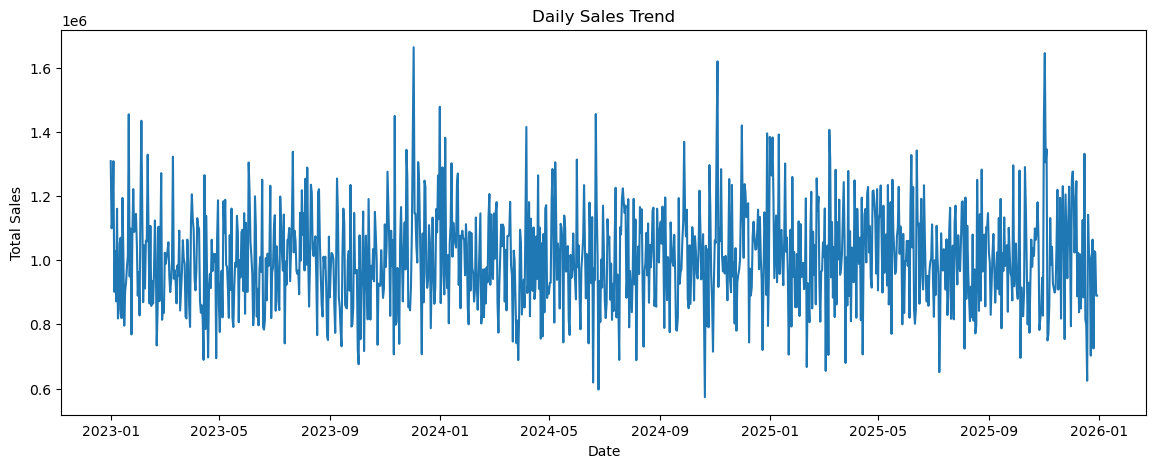

In [10]:
daily_sales = df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(14,5))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

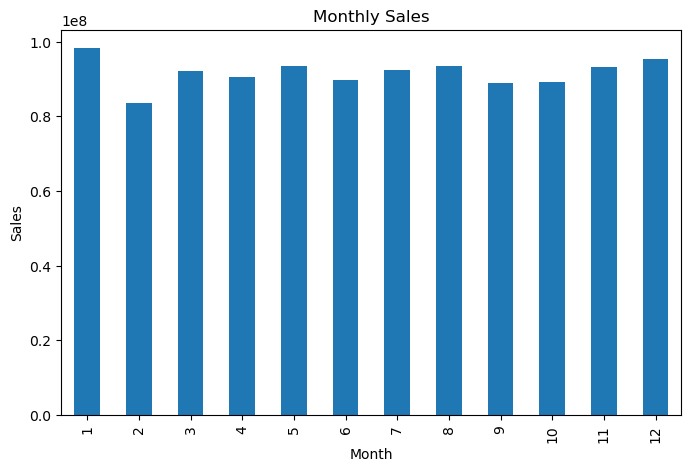

In [11]:
monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind="bar")
plt.title("Monthly Sales")
plt.ylabel("Sales")
plt.show()

In [12]:
df.groupby("Promotion")["Sales"].mean()

Promotion
No     26716.615989
Yes    34758.166058
Name: Sales, dtype: float64

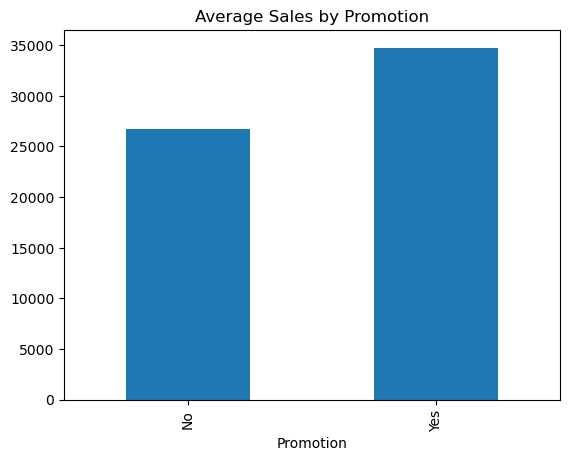

In [13]:
promotion_sales = df.groupby("Promotion")["Sales"].mean()

promotion_sales.plot(kind="bar")
plt.title("Average Sales by Promotion")
plt.show()

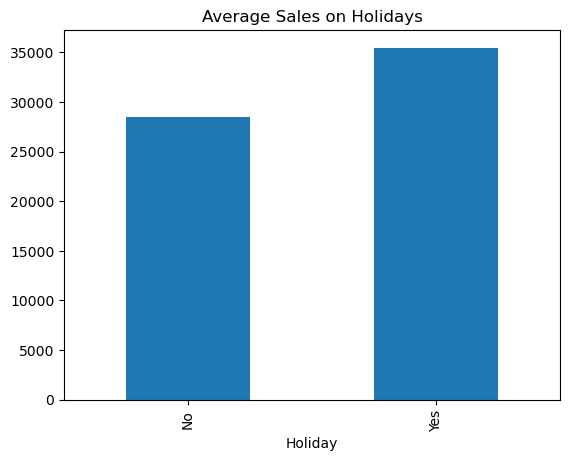

In [14]:
holiday_sales = df.groupby("Holiday")["Sales"].mean()

holiday_sales.plot(kind="bar")
plt.title("Average Sales on Holidays")
plt.show()

In [18]:
df.dtypes

Date           datetime64[ns]
Store_ID               object
Product_ID             object
Category               object
Region                 object
Price                   int64
Units_Sold              int64
Promotion              object
Holiday                object
Temperature           float64
Rainfall              float64
Sales                   int64
Year                    int32
Month                   int32
Day                     int32
Weekday                 int32
dtype: object

In [19]:
df["Promotion"] = df["Promotion"].map({
    "No": 0,
    "Yes": 1
})

df["Holiday"] = df["Holiday"].map({
    "No": 0,
    "Yes": 1
})

In [20]:
df[["Promotion","Holiday"]].head()

,Promotion,Holiday
0,1,1
1,0,1
2,0,1
3,0,1
4,1,1


In [21]:
X = df[
[
    "Price",
    "Units_Sold",
    "Promotion",
    "Holiday",
    "Temperature",
    "Rainfall",
    "Month",
    "Day",
    "Weekday"
]
]

y = df["Sales"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
predictions = model.predict(X_test)

In [25]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 6857.543596817228
RMSE: 9524.553503660904
R2 Score: 0.8684565279343961


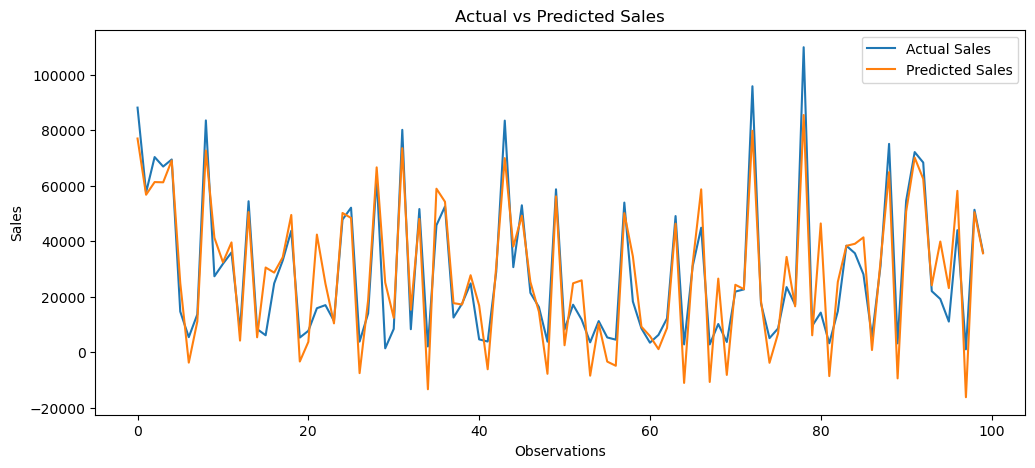

In [26]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:100], label="Actual Sales")
plt.plot(predictions[:100], label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Observations")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [27]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
1,Units_Sold,369.045478
0,Price,77.652195
5,Rainfall,30.436498
8,Weekday,14.868190
7,Day,11.227215
4,Temperature,10.695658
6,Month,10.614348
2,Promotion,-25.038756
3,Holiday,-243.561850


# Business Insights

1. Promotions positively influence sales performance.

2. Holiday periods impact customer purchasing behavior.

3. Units Sold is one of the strongest predictors of sales.

4. Weather conditions show some relationship with sales demand.

5. Seasonal patterns can be observed across different months.

# Conclusion

A Linear Regression model was developed to forecast sales using historical business data.

The model achieved:

- MAE: 6857.54
- RMSE: 9524.55
- R² Score: 0.868

The high R² score indicates that the model explains approximately 86.8% of the variation in sales data.

The forecasting model can support inventory planning, demand forecasting, and business decision-making.

# Future Improvements

1. Experiment with Random Forest Regressor.
2. Apply XGBoost for better accuracy.
3. Build a Time Series Forecasting model using ARIMA or Prophet.
4. Incorporate additional business factors.
5. Deploy the model as a dashboard application.